# What drives Airbnb prices in Porto? A Data-driven Analysis

**Author**: Carolina Dias | **Dataset:** Inside Airbnb - Porto listings | **Date:** 2026

---

## Overview

Tourism in Portugal has been growing considerably in the last decade, and Porto is one of the most popular destinations. With thousands of listings spread across 17 municipalities, from the tourist-dense historic centre to quieter coastal towns, understanding what drives accomodation prices is valuable for hosts, guests, and investors alike.

This notebook investigates:
1. **What factors most influence listing prices** (room type, neighbourhood, host type)
2. **How host behaviour clusters** across the market (professional vs. casual operators)
3. **Whether we can predict price** and identify listings that over- or under-charge relative to their characteristics

**Key findings are summarised in the [Conclusions](#conclusions) section at the end.**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms 
import seaborn as sns
import geopandas as gpd
from dash import Dash,dcc,html,Input,Output
import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# Import dataset
porto = pd.read_csv("data/listings.csv")
neigh = pd.read_csv("data/neighbourhoods.csv")
porto = porto.copy()

# Data Cleaning
cols_to_drop = ["name", "host_id", "host_name", "reviews_per_month", "last_review", "number_of_reviews_ltm", "license"]
porto_df = porto.drop(columns=cols_to_drop, inplace=False)
porto_df = porto_df[porto_df["availability_365"] > 0]
porto_df = porto_df[porto_df["minimum_nights"] <= 3] ## 3rd quantile = 2 days so limit is set to 3 days
porto_df = porto_df[porto_df["price"] <= 500]
porto_df = porto_df.dropna(subset=["price"])

# Feature engineering
porto_df["total_min_cost"] = porto_df["minimum_nights"] * porto_df["price"]
porto_df["professional_host"] = (porto_df["calculated_host_listings_count"] > 3)

## Exploratory Data Analysis

### 4.1 Price & Cost Distributions

### 4.2. Listings by Neighboourhood and Room Type

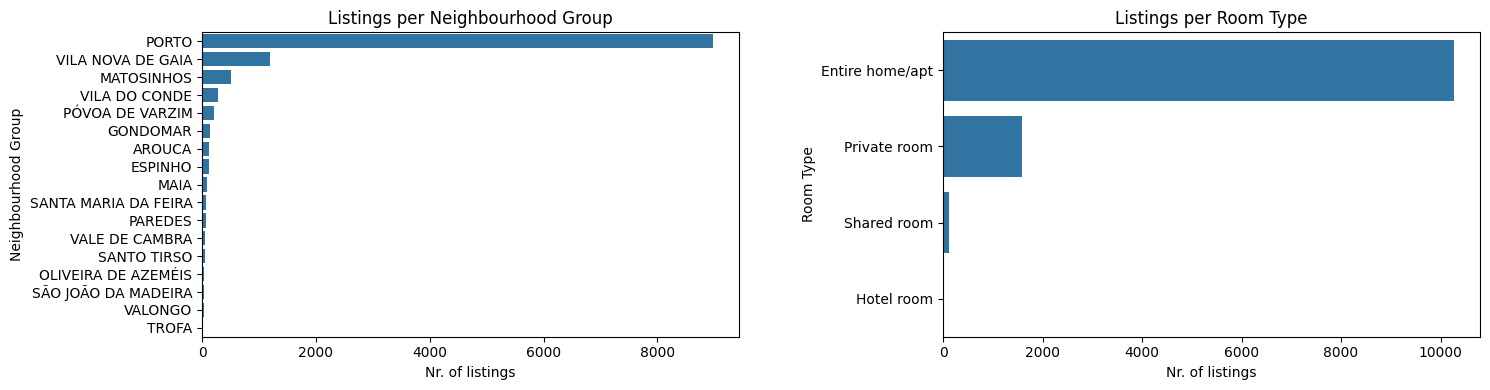

In [2]:
# number of listings by neighbourhood group + room type
counts = porto_df.groupby("neighbourhood_group").size().reset_index(name="count")
counts = counts.sort_values(by="count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=counts, y="neighbourhood_group", x="count", order=counts["neighbourhood_group"], ax = axes[0])
axes[0].set_xlabel("Nr. of listings")
axes[0].set_ylabel("Neighbourhood Group")
axes[0].set_title("Listings per Neighbourhood Group")


# number of listings by room type
counts_room = porto_df.groupby("room_type").size().reset_index(name="count")
counts_room = counts_room.sort_values(by="count", ascending=False)
sns.barplot(data=counts_room, y="room_type", x="count", order=counts_room["room_type"], ax = axes[1])
axes[1].set_xlabel("Nr. of listings")
axes[1].set_ylabel("Room Type")
axes[1].set_title("Listings per Room Type")

plt.tight_layout()
plt.subplots_adjust(wspace=0.38)   
plt.show()


### 4.3 Price Distribution Across Municipalities

The ridge plot below shows how price distributions differ across all 17 municipalities.
The vertical black line marks each area's **median price**. We would expect to observe the **highest** prices in the most **touristic** municipalities, such as Porto and Matosinhos. Yet, results show otherwise - Matosinhos is the 5th cheapest municipality and Porto is in middle rank. Conversely, **Trofa** and **Santo Tirso** stand out as the two most **expensive** regions, which interestingly are outside Porto's metropolitan area. 

It's worth noting that **number of listings** play an important role in the results we observed. Porto, having the most accomodation density, follows a normal distribution. In contrast, São João da Madeira, Valongo and Trofa have very few listings.

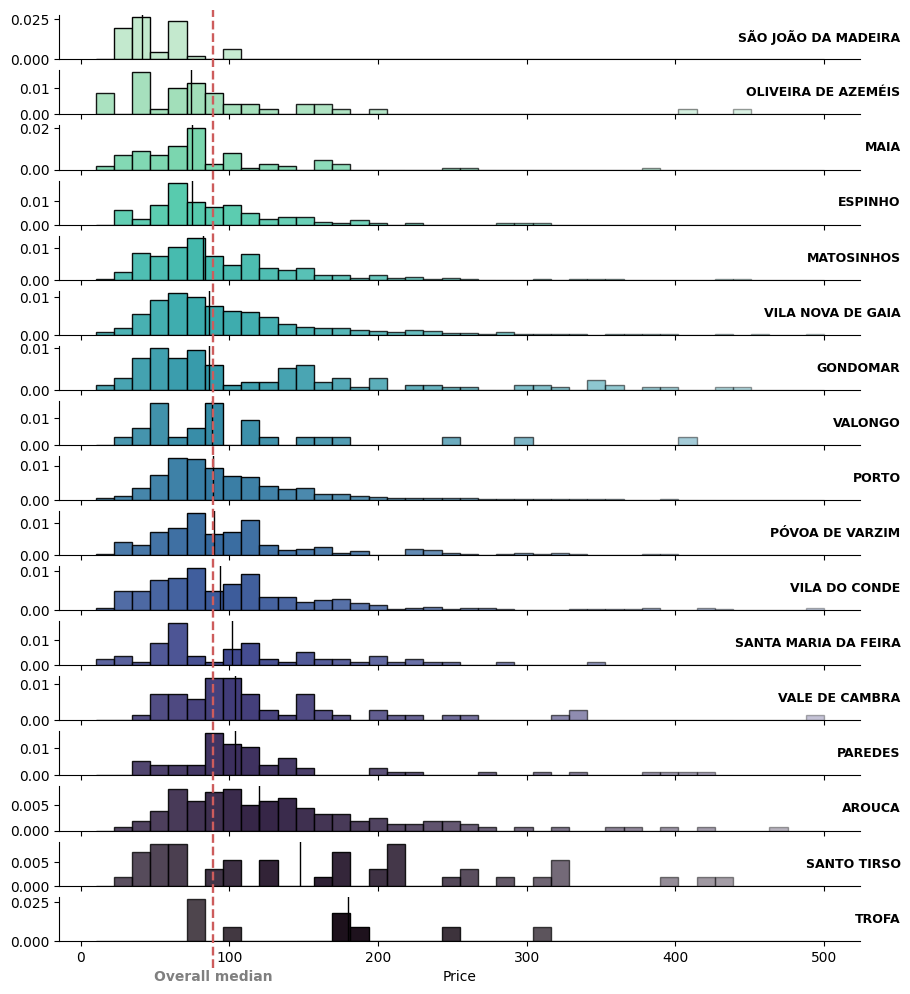

In [3]:
overall_median = porto_df['price'].median()
order = (porto_df.groupby('neighbourhood_group')['price'].median().sort_values().index)
global_bins = np.histogram_bin_edges(porto_df['price'], bins=40)

palette = sns.color_palette("mako", len(order))
palette = list(reversed(palette))
pal_dict = dict(zip(order, palette))

g = sns.FacetGrid(porto_df, row="neighbourhood_group", row_order=order,
    hue="neighbourhood_group", palette=pal_dict, height=0.6, aspect=15, sharex=True, sharey=False)

g.map(sns.histplot, "price", bins=global_bins, stat='density', alpha=0.9)
g.figure.subplots_adjust(hspace=0.25)

for ax, neigh in zip(g.axes.flat, order):
    neigh_median = porto_df.loc[porto_df['neighbourhood_group'] == neigh,'price'].median()
    ax.axvline(neigh_median, linewidth=1, color='black')
    ax.text(1.05, 0.5, neigh, transform=ax.transAxes, ha='right', va='center', fontsize=9, fontweight='bold')
    ax.set_title("")
    patches = ax.patches
    
    if patches:
        centers = [
            p.get_x() + p.get_width()/2
            for p in patches]
        max_dist = max(abs(c - neigh_median) for c in centers) + 1e-6

        for p, c in zip(patches, centers):
            dist = abs(c - neigh_median) / max_dist
            alpha = 1 - 0.7 * dist
            p.set_alpha(alpha)

g.set_xlabels("Price")
g.set_ylabels("")

# continuous overall median line
blended_trans = transforms.blended_transform_factory(
    g.axes.flat[0].transData, 
    g.figure.transFigure)

line = plt.Line2D([overall_median, overall_median], [0.03, 0.97],
    transform=blended_trans, color="indianred", linestyle="dashed", linewidth=1.7)

g.figure.add_artist(line)

# --- Add text label at the bottom ---
g.figure.text(overall_median, 0.015, "Overall median", transform=blended_trans, color="grey",           
    ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.show()

### 4.4. Interactive Map



Below, we find a map where we can explore the two relevant variables - **price** and **availability**. By looking at the price, we can get a better perspective of the **regional** and individual differences. Conversely, the availability helps us distinguish between the registered and the rentable listings. We can also explore different types of **filters** to assess the effect that it has on availability or price or both.

In [ ]:
# import geospatial data
prt2 = gpd.read_file("data/PRT_2.shp")
mun = gpd.read_file("data/portugal_municipios.geojson")
porto_geo = mun[mun["name_1"] == "Porto"] # subset where name_1 == 'Porto'

# create Dash app
app=Dash(__name__)
porto_df["price"]=porto_df["price"].astype(float)
geojson=porto_geo.to_json()

controls=html.Div(style={"position":"absolute","top":"20px","left":"20px","zIndex":999,
                         "backgroundColor":"black","padding":"15px",
                         "borderRadius":"10px","color":"white","fontFamily":"Verdana","display":"flex",
                         "flexDirection":"column","gap":"14px"},children=[
html.H4("Porto Airbnb Map"),

html.Label("Color Variable"),
dcc.RadioItems(id="color_var",options=[{"label":"Availability","value":"availability_365"},{"label":"Price","value":"price"}],value="availability_365",inline=True),

html.Label("Room Type"),
dcc.Dropdown(id="room",options=[{"label":i,"value":i} for i in porto_df["room_type"].unique()],multi=True, style={"color":"black","backgroundColor":"white"}),

html.Label("Neighbourhood Group"),
dcc.Dropdown(id="neigh",options=[{"label":i,"value":i} for i in porto_df["neighbourhood_group"].unique()],multi=True, style={"color":"black","backgroundColor":"white"})])

app.layout=html.Div(style={"backgroundColor":"black"},children=[controls,dcc.Graph(id="map",style={"height":"100vh"})])
@app.callback(Output("map","figure"),Input("room","value"),Input("neigh","value"),Input("color_var","value"))

def update_map(room,neigh,color_var):
    df=porto_df.copy()
    if room: df=df[df["room_type"].isin(room)]
    if neigh: df=df[df["neighbourhood_group"].isin(neigh)]

    fig=px.scatter_map(df,lat="latitude",lon="longitude",color=color_var,zoom=11, color_continuous_scale="Plasma",map_style="carto-darkmatter")
    fig.update_layout(paper_bgcolor="black",plot_bgcolor="black", font=dict(family="Verdana",color="white"), coloraxis_colorbar=dict(title=color_var), 
                      mapbox_layers=[{"source":geojson,"type":"line","color":"cyan","line":{"width":1}}], margin=dict(r=0,t=0,l=0,b=0))
    return fig

app.run(debug=False, port=8051)


ObsoleteAttributeException: app.run_server has been replaced by app.run

### 4.5. Professional vs. Casual Hosts

We define a **professional host** as one managing more than 3 listings simultaneously.
These operators make up a minority of hosts but behave differently from the casual host listings. Interestingly, the price distribution is similar in both groups. The main difference relies in the minimum nights requirement - one-night stays are provided in majority by professional hosts, while casual hosts prefer to set a two-night minimum.

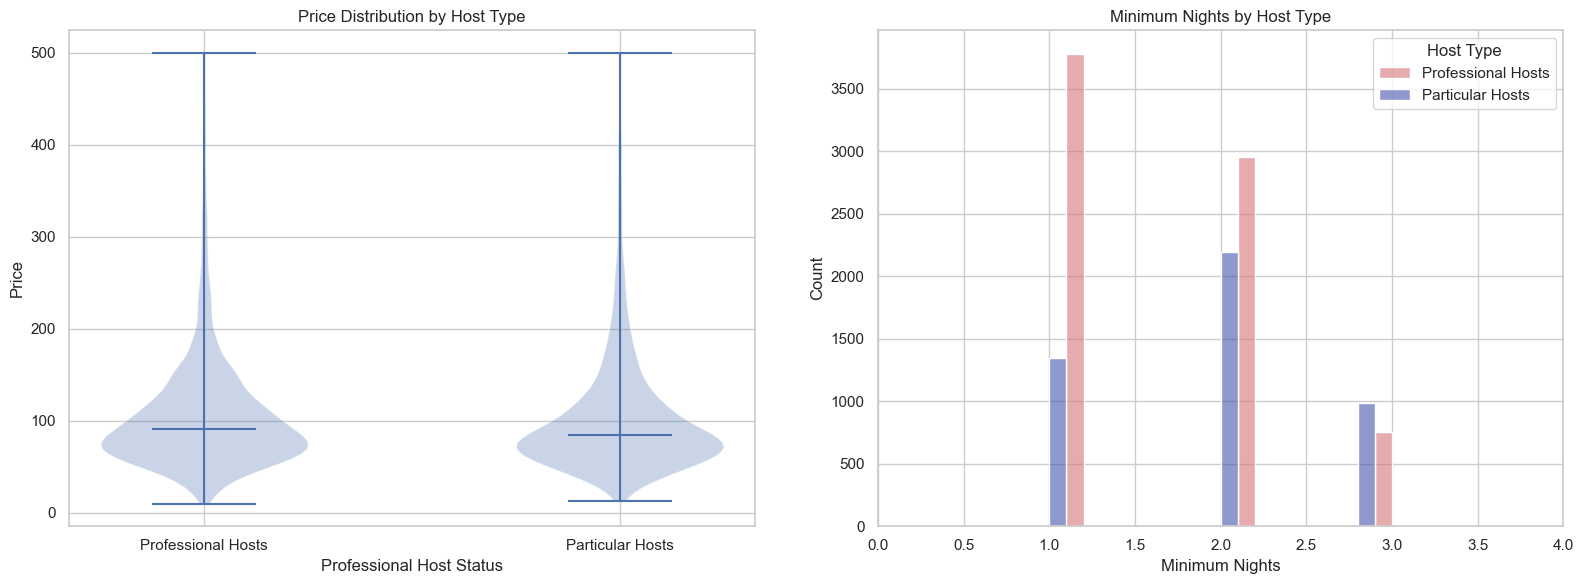

In [ ]:
# Professional hosts vs casual hosts - price and total minimum cost distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price
axes[0].violinplot([porto_df[porto_df["professional_host"]]["price"], porto_df[~porto_df["professional_host"]]["price"]], showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Professional Hosts", "Particular Hosts"])
axes[0].set_ylabel("Price")
axes[0].set_xlabel("Professional Host Status")
axes[0].set_title("Price Distribution by Host Type")

# Total Minimum Cost
sns.histplot(data=porto_df, x="minimum_nights", hue="professional_host", multiple="dodge", palette=["#4555ae","#d67476"], bins=10, alpha=0.6, ax=axes[1])
axes[1].set_xlabel("Minimum Nights")
axes[1].set_ylabel("Count")
axes[1].set_title("Minimum Nights by Host Type")
axes[1].legend(title="Host Type", loc="upper right", labels=["Professional Hosts", "Particular Hosts"])
axes[1].set_xlim(0, 4)  # optional to focus on realistic range

plt.tight_layout()
plt.subplots_adjust(wspace=0.18)   
plt.show()


## 5. Host Behaviour Clustering (DBSCAN)

We use **DBSCAN** (Density-Based Spatial Clustering) rather than KMeans for this analysis because:
- It does not require specifying the number of clusters in advance
- It naturally handles noise/outliers (labelled cluster `-1`)
- Host behaviour data is likely to form irregular, non-spherical clusters

**Features used:** log-price, availability (days/year), number of listings per host, professional host flag.

We first use a k-nearest-neighbours distance plot to tune the `eps` parameter.

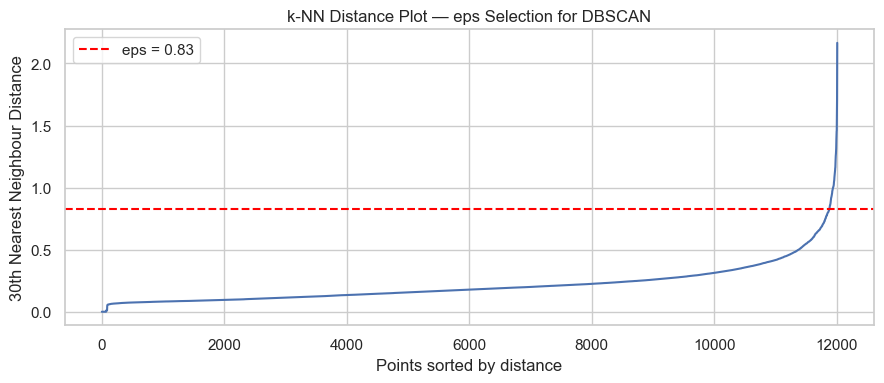

In [ ]:
# Prepare features for clustering
porto_df['price_log'] = np.log1p(porto_df['price'])
porto_df['professional_host_int'] = porto_df['professional_host'].astype(int)

features = ['price_log', 'availability_365', 'calculated_host_listings_count', 'professional_host_int']
X = porto_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Fit DBSCAN with chosen eps
db = DBSCAN(eps=0.83, min_samples=30)
porto_df['cluster'] = db.fit_predict(X_scaled)

n_clusters = len(set(porto_df['cluster'])) - (1 if -1 in porto_df['cluster'].values else 0)
n_noise = (porto_df['cluster'] == -1).sum()
print(f"Clusters found: {n_clusters}  |  Noise points: {n_noise} ({n_noise/len(porto_df)*100:.1f}%)")

# Cluster summary
summary = porto_df.groupby('cluster')[features + ['price']].median().round(2)
summary.index.name = 'Cluster (-1 = noise)'
summary

Clusters found: 3  |  Noise points: 17 (0.1%)


,price_log,availability_365,calculated_host_listings_count,professional_host_int,price
Cluster (-1 = noise),,,,,
-1,4.76,77.0,403.0,1.0,116.0
0,4.45,287.5,1.0,0.0,85.0
1,4.51,315.0,11.0,1.0,90.0
2,4.60,292.0,403.0,1.0,98.0


**Interpreting the clusters:**

| Cluster | Interpretation |
|---------|---------------|
| **0** | Budget listings — lower price, limited availability, mostly casual hosts |
| **1** | Mid-market listings — moderate price and availability, mix of host types |
| **2** | Professional operators — high listing counts, strong availability, premium pricing |
| **-1 (noise)** | Atypical listings that don't fit any cluster — worth examining individually |

*Note: re-run and update the table above after observing actual median values from the summary output.*

## 6. Price Prediction with Random Forest

Can we predict nightly price from listing features? A **Random Forest Regressor** is well-suited here:
it handles non-linear relationships, doesn't require feature scaling, and produces interpretable feature importances.

We predict **log-price** (to reduce skew) and report both R² and Mean Absolute Error (MAE) in the original € scale.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# One-hot encode room_type if not already done
porto_model = porto_df.copy()
porto_model = pd.get_dummies(porto_model, columns=["room_type"], drop_first=True)

model_features = ['availability_365', 'minimum_nights', 'calculated_host_listings_count',
                  'professional_host_int', 'number_of_reviews', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

X_model = porto_model[model_features].fillna(0)
y_model = np.log1p(porto_model['price'])

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_actual, y_pred)

print(f"R²  (log-price): {r2:.3f}")
print(f"MAE (€):         {mae:.2f}")

R²  (log-price): 0.297
MAE (€):         39.31


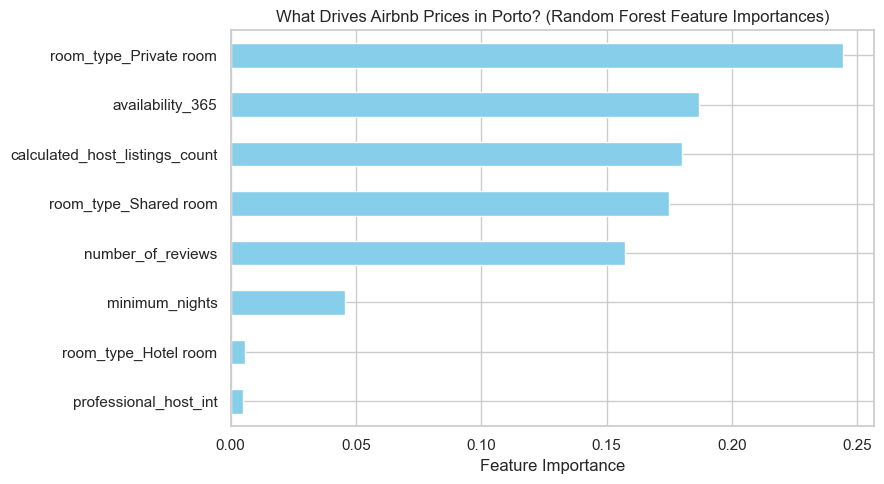

In [ ]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color="skyblue")
plt.xlabel("Feature Importance")
plt.title("What Drives Airbnb Prices in Porto? (Random Forest Feature Importances)")
plt.tight_layout()
plt.show()

## 7. Conclusions <a name="conclusions"></a>

---

### Key Findings

1. **Room type is the strongest price driver.** Entire homes/apartments command the highest prices; hotel rooms and shared rooms sit at the bottom. This is the single most important feature in the Random Forest model.

2. **Porto city dominates in volume, but not in price.** It accounts for the majority of listings and earned a middle rank in price, when comparing with other municipalities. Outer municipalities (São João da Madeira and Valongo) cluster around much lower, tighter price bands.

3. **Professional hosts charge more, but not always.** Hosts with >3 listings tend to have higher median prices and availability, but the effect is modest compared to room type and location.

4. **DBSCAN identifies 3 distinct host profiles:** budget/casual, mid-market, and professional operators — with a meaningful share of noise points representing atypical listings.

5. **Price is not very predictable from listing features alone.** The Random Forest achieves an R² of ~0.3 on log-price. The remaining variance likely comes from unobserved factors: interior quality, decor, proximity to landmarks, and reviews. Additional features should be radded to the Airbnb dataset to improve model performance.

---

### Limitations & Next Steps

- **No review sentiment** — incorporating NLP on review text could significantly improve price prediction.
- **No temporal data** — seasonal pricing patterns are not captured in a single snapshot.
- **Proximity features** — distance to metro stations, city centre, or tourist landmarks would likely improve the model.
- **Causal inference** — this analysis is descriptive; identifying causal price drivers would require a more rigorous design.

---

*Data source: [Inside Airbnb](http://insideairbnb.com/) — Porto listings snapshot.*
